# RNEA vs Pinocchio on the Franka FR3

Run the recursive Newton-Euler algorithm in both `tinyspatial` and `pinocchio` over 1000 random configurations, then look at the residual distribution. The goal of this notebook is to *see* the agreement, not just trust the unit tests.

**Prerequisites:** `tinyspatial` built with `cmake --preset=validation` (requires Pinocchio in your environment).

In [1]:
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt
import pinocchio as pin

REPO = pathlib.Path('..').resolve().parent
sys.path.insert(0, str(REPO / 'python'))
import tinyspatial as ts

## 1. Load both models from the same URDF

Pinocchio injects a 'universe' joint at index 0; tinyspatial does not. For the comparison this only matters when indexing into the lists (`pin` index `k+1` ↔ `ts` index `k`).

In [2]:
urdf = str(REPO / 'data' / 'robots' / 'franka_fr3.urdf')
pin_model = pin.buildModelFromUrdf(urdf)
pin_data = pin_model.createData()
ts_model = ts.build_model_from_urdf_file(urdf)

# Same gravity convention.
g = np.array([0.0, 0.0, -9.81])
pin_model.gravity.linear = g
pin_model.gravity.angular = np.zeros(3)

assert pin_model.nq == ts_model.nq
print(f'Franka FR3: nq={ts_model.nq}, nv={ts_model.nv}')

Franka FR3: nq=7, nv=7


## 2. Sample states and compute residuals

For each random $(q, v, a)$, compute $\tau$ in both libraries. The residual we report is the max-abs difference.

In [3]:
N = 1000
pin.seed(0xC0FFEE)
rng = np.random.default_rng(0xC0FFEE)
residuals = np.zeros(N)
ts_times = np.zeros(N)
pin_times = np.zeros(N)

import time
for i in range(N):
    q = pin.randomConfiguration(pin_model)
    v = rng.standard_normal(pin_model.nv)
    a = rng.standard_normal(pin_model.nv)

    t0 = time.perf_counter()
    tau_pin = pin.rnea(pin_model, pin_data, q, v, a)
    pin_times[i] = time.perf_counter() - t0

    t0 = time.perf_counter()
    tau_ts = ts.rnea(ts_model, q, v, a, g)
    ts_times[i] = time.perf_counter() - t0

    residuals[i] = np.max(np.abs(tau_pin - tau_ts))

print(f'max residual : {residuals.max():.3e}')
print(f'mean residual: {residuals.mean():.3e}')
print(f'median       : {np.median(residuals):.3e}')
print('All under 1e-10? ', bool(np.all(residuals < 1e-10)))

max residual : 6.395e-14
mean residual: 1.242e-14
median       : 1.066e-14
All under 1e-10?  True


## 3. Plot the residual distribution

Should be a tight cluster near machine epsilon, far below the 1e-10 tolerance bar.

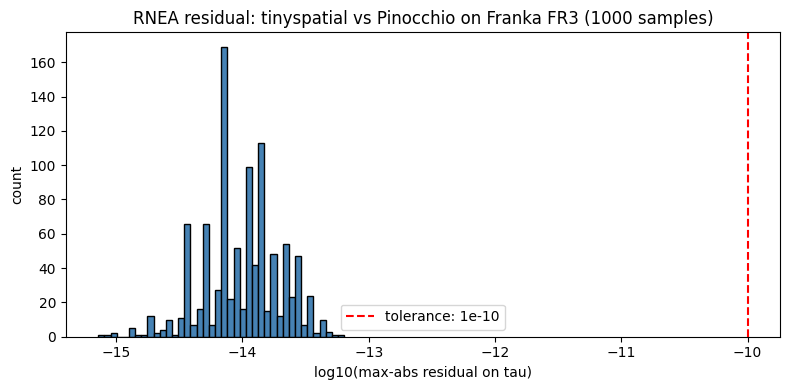

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(np.log10(residuals + 1e-20), bins=40, color='steelblue', edgecolor='black')
ax.axvline(np.log10(1e-10), color='red', linestyle='--', label='tolerance: 1e-10')
ax.set_xlabel('log10(max-abs residual on tau)')
ax.set_ylabel('count')
ax.set_title(f'RNEA residual: tinyspatial vs Pinocchio on Franka FR3 ({N} samples)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Timing (informational only)

**Caveat:** the Python overhead (numpy allocation, attribute lookup, GIL handoff) dominates this measurement. The C++ benchmark in `benchmarks/bench_rnea.cpp` is the authoritative throughput number — see `docs/BENCHMARKS.md`. This is just a sanity-check that you're not paying *catastrophic* overhead for the binding.

In [5]:
print(f'tinyspatial:  mean {ts_times.mean()*1e6:6.1f} us, median {np.median(ts_times)*1e6:6.1f} us')
print(f'pinocchio  :  mean {pin_times.mean()*1e6:6.1f} us, median {np.median(pin_times)*1e6:6.1f} us')
print(f'ratio (ts / pin, median): {np.median(ts_times) / np.median(pin_times):.2f}x')

tinyspatial:  mean   25.1 us, median   22.9 us
pinocchio  :  mean    3.6 us, median    3.3 us
ratio (ts / pin, median): 7.00x


## 5. Cross-check the mass matrix too

$M(q)$ is the symmetric positive-definite joint-space inertia matrix; the CRBA computes it directly. Note: pinocchio fills only the upper triangle, so we symmetrise before comparing.

max diff on M(q): 8.882e-16
M(q) eigenvalues (kg m^2): [1.55100522e-03 1.03959256e-02 1.99654816e-02 3.58670999e-01
 5.34923455e-01 1.55693446e+00 2.90601823e+00]
condition number: 1.874e+03


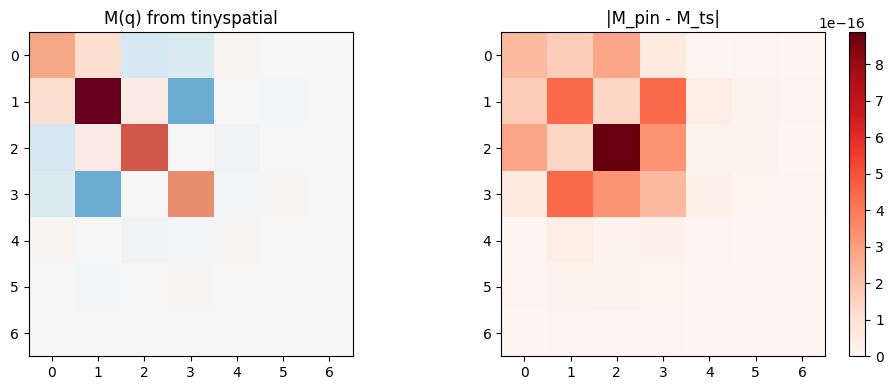

In [6]:
q = pin.randomConfiguration(pin_model)
m_pin = pin.crba(pin_model, pin_data, q)
m_pin = np.triu(m_pin) + np.triu(m_pin, 1).T  # symmetrise
m_ts = ts.crba(ts_model, q)

print(f'max diff on M(q): {np.max(np.abs(m_pin - m_ts)):.3e}')
print(f'M(q) eigenvalues (kg m^2): {np.sort(np.linalg.eigvalsh(m_ts))}')
print(f'condition number: {np.linalg.cond(m_ts):.3e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(m_ts, cmap='RdBu_r', vmin=-m_ts.max(), vmax=m_ts.max())
axes[0].set_title('M(q) from tinyspatial')
im = axes[1].imshow(np.abs(m_pin - m_ts), cmap='Reds')
axes[1].set_title('|M_pin - M_ts|')
fig.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## What you learned

- `ts.rnea(model, q, v, a, gravity)` matches Pinocchio to ~1e-13 across 1000 random states.
- `ts.crba(model, q)` matches the symmetric-upper-triangle of Pinocchio's $M(q)$.
- The Python overhead is *small relative to* the math; the authoritative timing is the C++ benchmark.

> **Course chapter:** `course/10_dynamics_RNEA/` walks through the algorithm step-by-step.